# ECON 398 Project Workbook

Authors: *William Clinton Co, Jerrold Huang, Jae Park, Kaiyan Zhang, Irene Berezin*

In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(haven)
library(lubridate)
library(stargazer)
library(units)
library(broom)
library(sf)
library(fixest)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


udunits database from C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4/units/s

### Data Preprocessing (Pulling Data for 2021 Census)

In [2]:
# reading in cancensus data for 2021
library(cancensus)
options(cancensus.api_key='CensusMapper_85cff6944226682c2124e67a6d1cc29c')
options(cancensus.cache_path = "/census_api")

census2021 <- get_census(dataset='CA21', 
regions=list(CSD="5915022"), vectors=c("v_CA21_1","v_CA21_6","v_CA21_386","v_CA21_906","v_CA21_5901", "v_CA21_4410"), 
labels="detailed", 
geo_format="sf", 
level='DA',
use_cache = FALSE)

census2021_clean <- census2021|>
    rename(
        geoid = `GeoUID`,
        households = Households, 
        dwellings = Dwellings, 
        population =  `v_CA21_1: Population, 2021`,
        population_density = `v_CA21_6: Population density per square kilometre`, 
        region = `Region Name`, 
        area_sq_km = `Area (sq km)`, 
        age =  `v_CA21_386: Average age`, 
        income = `v_CA21_906: Median total income of household in 2020 ($)`,
        education = `v_CA21_5901: University certificate or diploma above bachelor level`,
        immigrant = `v_CA21_4410: Immigrants`    
    )|>
    filter(region == "Vancouver")|>
    mutate(immigrant_prop = immigrant/population) |>
    mutate(education_prop = education / population)|>
    mutate(income = income / 100000)|>
    select(name, households, dwellings, population,population_density, region, area_sq_km, age, income, immigrant_prop, education_prop)|>
    glimpse()

census2021_st <- st_sf(census2021_clean, geometry = census2021_clean$geometry, crs = 4326)
census2021_centroid <- st_centroid(census2021_clean)

Warning message:
"package 'cancensus' was built under R version 4.4.2"


Census data is currently stored temporarily.

 In order to speed up performance, reduce API quota usage, and reduce unnecessary network calls, please set up a persistent cache directory via `set_cancensus_cache_path('<local cache path>', install = TRUE)`.
 This will add your cache directory as environment varianble to your .Renviron to be used across sessions and projects.



Querying CensusMapper API...



Downloading: 26 kB     

Querying CensusMapper API...



Downloading: 260 kB     Rows: 0
Columns: 12
$ name               <chr> 
$ households         <int> 
$ dwellings          <int> 
$ population         <dbl> 
$ population_density <dbl> 
$ region             <fct> 
$ area_sq_km         <dbl> 
$ age                <dbl> 
$ income             <dbl> 
$ immigrant_prop     <dbl> 
$ education_prop     <dbl> 
$ geometry           <GEOMETRY [°]> 


### Data Exploration

In [2]:
# Read in the 2016 census data
census2016 <- read_sf("census_index_crime.geojson")|>
    select(- c(crime_count, crime_rate))|>
    glimpse()

Rows: 993
Columns: 17
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.4…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

In [3]:
# Read in the crime data
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, neighbourhood, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2025)|>
    glimpse()

Rows: 380,225
Columns: 6
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ year          <int> 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2014, 2014, 20…
$ month         <int> 3, 8, 4, 8, 7, 11, 1, 4, 9, 1, 11, 11, 3, 6, 9, 6, 2, 2,…
$ name          <int> 59153689, 59153483, 59153483, 59153483, 59153483, 591534…
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


In [4]:

crime_data <- crime_data|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 207,379
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


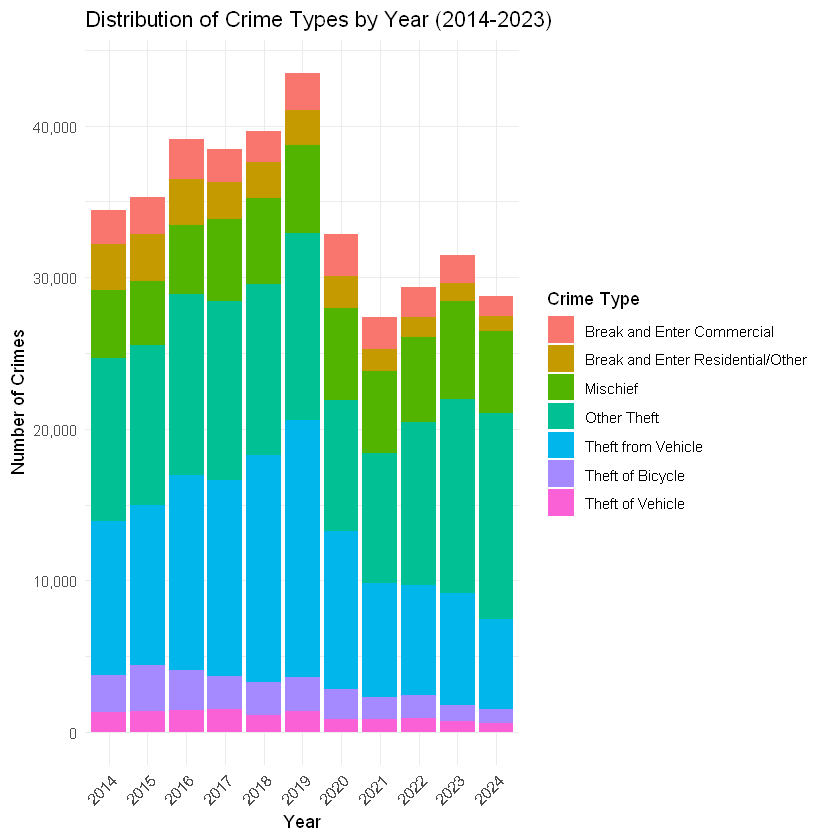

In [5]:
# Visualize the distribution of different types of crimes each year
crime_summary <- crime_data|>
  group_by(year, type)|>
  summarise(total_crimes = sum(crime_count, na.rm = TRUE))|>
  ungroup()

# Create the visualization
ggplot(crime_summary, aes(x = factor(year), y = total_crimes, fill = type)) +
  geom_col(position = "stack") +
  labs(title = "Distribution of Crime Types by Year (2014-2023)",
       x = "Year",
       y = "Number of Crimes",
       fill = "Crime Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right") +
  scale_y_continuous(labels = scales::comma)

The visualization showed some promise in heterogeneous analysis by different crime types, but let's first focus on crime overall, we remove "Mischief" because it is something not so interesting for our study.

In [6]:
# Create a data summarizing all types of crimes together
crime_trend <- crime_data|>
    filter(type != "Mischief")|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 112,655
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 1, 1, 4, 2, 1, 2, 1, 1, 3, 1, 2, 3, 1, 2, 3, 2, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [7]:
census2016_panel <- merge(census2016, crime_trend, by = "name")|>
    arrange(year, month)|>
    glimpse()

Rows: 112,655
Columns: 22
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [8]:
# Joining the neighborhood data
neighborhood <- read_sf("Boundary_data/local-area-boundary.geojson")|>
    rename("neighborhood" = "name")|>
    st_sf()

neighborhood_valid <- st_make_valid(neighborhood)
census2016_panel <- st_make_valid(census2016_panel)

census2016_panel <- st_simplify(census2016_panel, dTolerance = 0.01)
neighborhood_valid <- st_simplify(neighborhood_valid, dTolerance = 0.01)

desired_crs <- st_crs(neighborhood_valid)
census_index_crime_log <- st_transform(census2016_panel, crs = desired_crs)

census2016_panel <- st_join(census2016_panel, neighborhood_valid[, "neighborhood"], join = st_within)|>
    glimpse()

Rows: 112,655
Columns: 23
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [9]:
# Read in the NASA NTL data
ntl_data <- read_csv("NTL_data/NASA_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    select(!c(population, population_density))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    glimpse()

ntl_data$name <- as.character(ntl_data$name)

Rows: 154908 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (7): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 141,792
Columns: 6
$ name               <dbl> 59150307, 59150309, 59150311, 59150313, 59150328, 5…
$ ntl_mean           <dbl> 3.710000, 3.020000, 3.971038, 4.609642, 4.880000, 4…
$ n_pixels           <dbl> 5, 4, 4, 4, 3, 8, 4, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ n_non_na_pixels    <dbl> 1, 1, 2, 2, 1, 4, 4, 3, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ prop_non_na_pixels <dbl> 0.2000000, 0.2500000, 0.5000000, 0.5000000, 0.33333…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [10]:
# Merge 2 dataframes
census2016_panel <- census2016_panel|>
    left_join(ntl_data, by = c("name", "date"))|>
    glimpse()

Rows: 112,655
Columns: 27
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [11]:
crime_summary <- census2016_panel|>
    st_drop_geometry()|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
2.849949,47.61759,1,213


Since the crime data is highly volatile and affected by a lot of empty bins, and apparently it has a much larger variance comparing to its mean value. So instead of using the raw variable, we would employ a negative binomial regression to find its expected value given fixed effects of year, month, division, time_category, and we are using population density as an offset variable. 

In [12]:
census2016_panel <- census2016_panel|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    glimpse()

Rows: 112,655
Columns: 28
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [13]:
# load the necessary library
library(MASS)

# Coverting fixed effects as factors
census2016_panel$name <- as.factor(census2016_panel$name)
census2016_panel$year <- as.factor(census2016_panel$year)
census2016_panel$month <- as.factor(census2016_panel$month)
census2016_panel$time_category <- as.factor(census2016_panel$time_category)
census2016_panel$neighborhood <- as.factor(census2016_panel$neighborhood)

# Implementing the negative binomial regression
model_nb <- glm.nb(crime_count ~ name + year + month + time_category + offset(log(population_density)),
                   data = census2016_panel)

summary(model_nb)

Warning message:
"package 'MASS' was built under R version 4.4.2"

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select





Call:
glm.nb(formula = crime_count ~ name + year + month + time_category + 
    offset(log(population_density)), data = census2016_panel, 
    init.theta = 22.91864886, link = log)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -7.3293880  0.0788920 -92.904  < 2e-16 ***
name59150308       -0.8010912  0.1162084  -6.894 5.44e-12 ***
name59150309       -1.0855303  0.1018511 -10.658  < 2e-16 ***
name59150310       -0.5776584  0.0952820  -6.063 1.34e-09 ***
name59150311       -1.3271977  0.1169711 -11.346  < 2e-16 ***
name59150312       -1.2123833  0.1178710 -10.286  < 2e-16 ***
name59150313       -0.9216212  0.1082610  -8.513  < 2e-16 ***
name59150328       -0.1989466  0.1137848  -1.748 0.080387 .  
name59150329       -0.4006145  0.1087209  -3.685 0.000229 ***
name59150330       -1.2967576  0.1505344  -8.614  < 2e-16 ***
name59150331       -0.9787384  0.1178975  -8.302  < 2e-16 ***
name59150332       -1.2372170  0.1241795  -9.963  < 2e-16 *

In [19]:
census2016_panel$expected_crime <- predict(model_nb, type = "response")

glimpse(census2016_panel)

Rows: 112,655
Columns: 26
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 2.986096, 3.239346,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 1.812310, 3.605736,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.485976, 1.382670,…
$ mean_land_va

In [15]:
NBsummary <- census2016_panel|>
    st_drop_geometry()|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,2.814127,39.45146,0.7520295,119.3935
night,2.873353,41.57980,0.9028699,146.1237


In [16]:
# Read in data for electric price index
electric_index <- read_csv("electric_price_index.csv")|>
    dplyr::select(REF_DATE, Index, VALUE)|>
    filter(Index == "Electric power selling price under 5000kw")|>
    mutate(date = as.Date(paste0(REF_DATE, "-01")))|>
    rename("electric_index" = "VALUE")|>
    dplyr::select(date, electric_index)|>
    glimpse()

Rows: 264 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): REF_DATE, GEO, DGUID, Index, UOM, SCALAR_FACTOR, VECTOR
dbl (5): UOM_ID, SCALAR_ID, COORDINATE, VALUE, DECIMALS
lgl (3): STATUS, SYMBOL, TERMINATED

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 132
Columns: 2
$ date           <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-0…
$ electric_index <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7, 10…


In [17]:
census2016_panel <- census2016_panel|>
    left_join(electric_index, by = "date")|>
    glimpse()

Rows: 112,655
Columns: 30
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [18]:
# Save the data so we can start from here next time
census2016_panel <- census2016_panel|>
    st_drop_geometry()|>
    dplyr::select(-c(households, dwellings, region))

write_csv(census2016_panel, "census_2016_panel.csv")

### Panel Fixed Effect Model

With the data ready, we can run our first panel fixed effect model.

In [20]:
census2016_panel <- read_csv("census_2016_panel.csv")

Rows: 112655 Columns: 26
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): time_category, neighborhood
dbl  (23): name, population, population_density, area_sq_km, age, income, im...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [21]:
# Making necessary changes to the data
census2016_panel_night <- census2016_panel|>
    filter(time_category == "night")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(income = as.numeric(income), immigrant_prop = as.numeric(immigrant_prop), education_prop = as.numeric(education_prop))|>
    mutate(is_downtown = ifelse(is.na(is_downtown), 0, is_downtown))|>
    filter(!is.na(income), !is.na(education_prop), !is.na(immigrant_prop))|>
    glimpse()

Rows: 33,059
Columns: 26
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ education_prop       <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

In [27]:
# Adding day crime as a control
census2016_panel_day <- census2016_panel|>
    filter(time_category == "day")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(day_crime_count = crime_count, expected_day_crime = expected_crime)|>
    dplyr::select(name, date, day_crime_count, expected_day_crime)

census2016_panel_night <- census2016_panel_night|>
    left_join(census2016_panel_day, by = c("name", "date"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(expected_day_crime = ifelse(is.na(expected_day_crime), 0, expected_day_crime))|>
    glimpse()

Rows: 33,059
Columns: 28
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ education_prop       <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

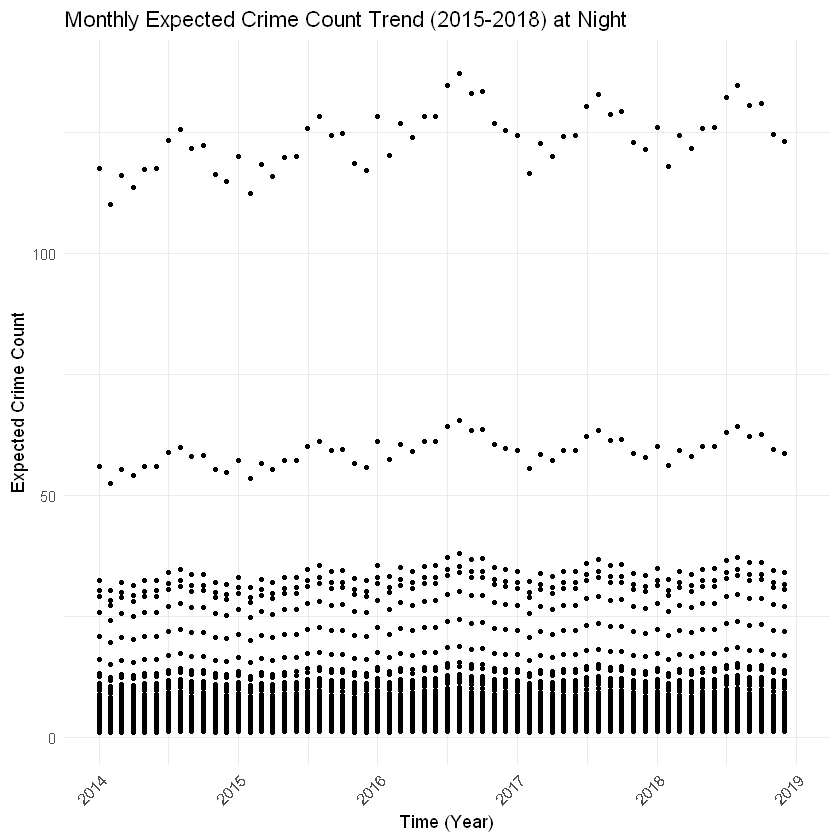

In [28]:
ggplot(census2016_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2015-2018) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

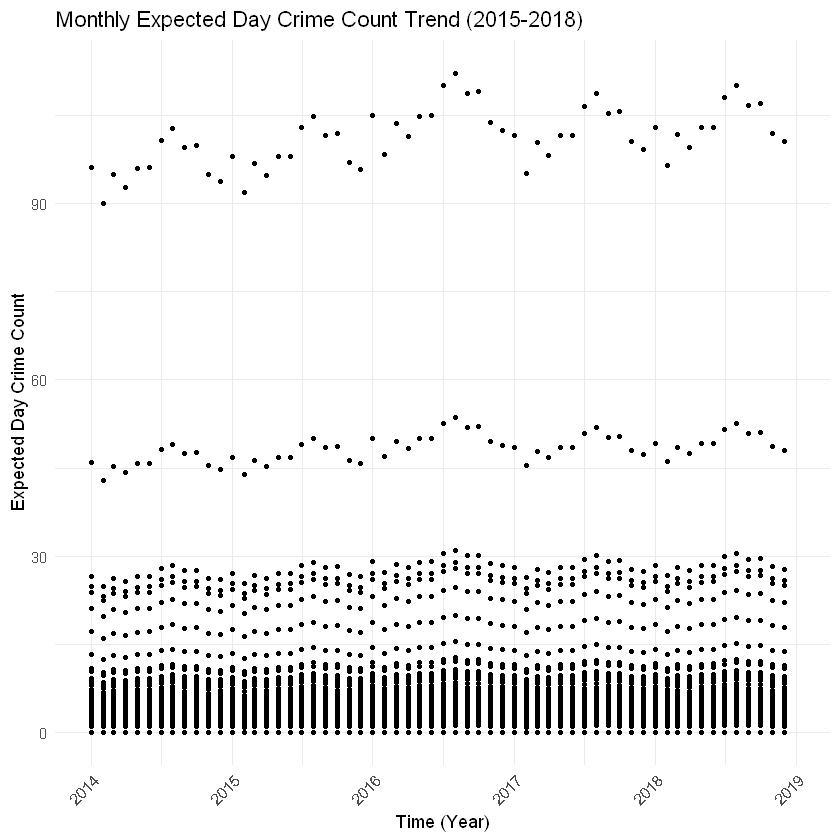

In [29]:
ggplot(census2016_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Day Crime Count", 
       title = "Monthly Expected Day Crime Count Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 2667 rows containing non-finite outside the scale range
(`stat_smooth()`)."


Warning message:
"Removed 2667 rows containing missing values or values outside the scale range
(`geom_point()`)."


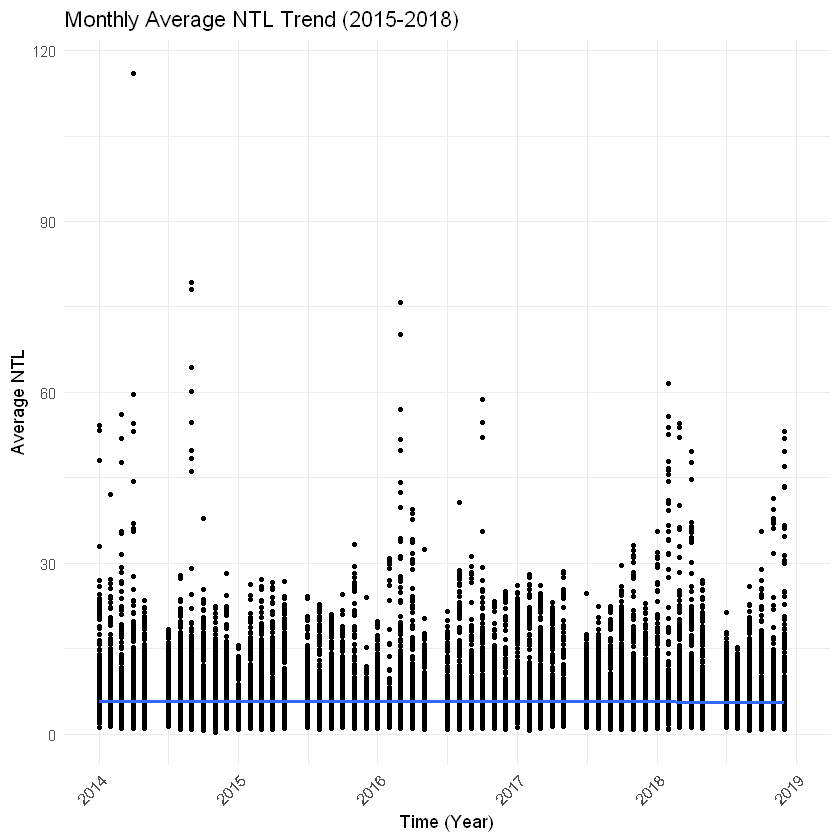

In [30]:
ggplot(census2016_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [ ]:
model0 <- expected_crime ~ ntl_mean + electric_index + expected_day_crime + is_downtown | year + month

model_fe0 <- feols(model0, data = census2016_panel_night)

summary(model_fe0)

NOTE: 2,667 observations removed because of NA values (RHS: 2,667).



OLS estimation, Dep. Var.: expected_crime
Observations: 30,392
Fixed-effects: year: 5,  month: 11
Standard-errors: Clustered (year) 
                    Estimate Std. Error     t value   Pr(>|t|)    
ntl_mean           -0.011958   0.002742   -4.361818 1.2045e-02 *  
electric_index     -0.002018   0.009078   -0.222280 8.3498e-01    
expected_day_crime  1.180839   0.000670 1761.331277 6.2343e-13 ***
is_downtown        -0.160017   0.039769   -4.023621 1.5817e-02 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.853845     Adj. R2: 0.982934
                 Within R2: 0.982938

In [77]:
model0 <- expected_crime ~ ntl_mean*is_downtown + electric_index + expected_day_crime

model_fe0 <- feols(model0, data = census2016_panel_night)

summary(model_fe0)

NOTE: 2,667 observations removed because of NA values (RHS: 2,667).



OLS estimation, Dep. Var.: expected_crime
Observations: 30,392
Standard-errors: IID 
                      Estimate Std. Error    t value   Pr(>|t|)    
(Intercept)           0.748777   0.082063    9.12441  < 2.2e-16 ***
ntl_mean             -0.016508   0.001582  -10.43562  < 2.2e-16 ***
is_downtown          -0.316354   0.045932   -6.88745 5.7905e-12 ***
electric_index        0.002744   0.000740    3.70769 2.0953e-04 ***
expected_day_crime    1.181755   0.000996 1186.73299  < 2.2e-16 ***
ntl_mean:is_downtown  0.012360   0.002828    4.37021 1.2454e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.85578   Adj. R2: 0.982864

In [45]:
library(plm)

Warning message:
"package 'plm' was built under R version 4.4.3"

Attaching package: 'plm'


The following objects are masked from 'package:dplyr':

    between, lag, lead




In [84]:
fe_model_time_controls <- plm(expected_crime ~ ntl_mean * is_downtown + month, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(fe_model_time_controls)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + month, 
    data = census2016_panel_night, effect = "individual", model = "within", 
    index = c("name", "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-13.2930835  -0.0592697   0.0022873   0.0630807  13.4531528 

Coefficients:
                       Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.0162100  0.0013289 -12.1980 < 2.2e-16 ***
month10               0.1121804  0.0090946  12.3348 < 2.2e-16 ***
month11              -0.0408639  0.0091184  -4.4815 7.441e-06 ***
month12              -0.0810004  0.0091142  -8.8873 < 2.2e-16 ***
month2               -0.1869508  0.0094098 -19.8678 < 2.2e-16 ***
month3               -0.0231080  0.0093674  -2.4669   0.01364 *  
month4               -0.0913274  0.0093797  -9.7367 < 2.2e-16 ***
month5                0.0029429  0.0092958   0.3166   0.

In [38]:
model1 <- expected_crime ~ ntl_mean + electric_index + expected_day_crime + is_downtown + population_density + income | year + month

model_fe1 <- feols(model1, data = census2016_panel_night)

summary(model_fe1)

NOTE: 2,667 observations removed because of NA values (RHS: 2,667).



OLS estimation, Dep. Var.: expected_crime
Observations: 30,392
Fixed-effects: year: 5,  month: 11
Standard-errors: Clustered (year) 
                      Estimate  Std. Error     t value   Pr(>|t|)    
ntl_mean           -0.01026889 0.002569598   -3.996303 1.6180e-02 *  
electric_index     -0.00313745 0.009347634   -0.335641 7.5401e-01    
expected_day_crime  1.18212620 0.000651607 1814.171431 5.5391e-13 ***
is_downtown        -0.25734321 0.032763035   -7.854682 1.4194e-03 ** 
population_density  0.00000442 0.000000707    6.242020 3.3571e-03 ** 
income              0.30517576 0.044455442    6.864756 2.3582e-03 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.850869     Adj. R2: 0.983052
                 Within R2: 0.983057

In [39]:
model_count0 <- crime_count ~ ntl_mean + electric_index + day_crime_count | year + month

model_fe_count0 <- feols(model_count0, data = census2016_panel_night)

summary(model_fe_count0)

NOTE: 2,667 observations removed because of NA values (RHS: 2,667).



OLS estimation, Dep. Var.: crime_count
Observations: 30,392
Fixed-effects: year: 5,  month: 11
Standard-errors: Clustered (year) 
                Estimate Std. Error   t value   Pr(>|t|)    
ntl_mean        0.131256   0.010359 12.671238 2.2339e-04 ***
electric_index  0.007328   0.042944  0.170653 8.7278e-01    
day_crime_count 0.962788   0.025386 37.925826 2.8867e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2.7347     Adj. R2: 0.827255
               Within R2: 0.827249

In [11]:
model_count1 <- crime_count ~ ntl_mean + electric_index + day_crime_count + population_density + income | year + month

model_fe_count1 <- feols(model_count1, data = census2016_panel_night)

summary(model_fe_count1)

NOTE: 2,907 observations removed because of NA values (RHS: 2,907).



OLS estimation, Dep. Var.: crime_count
Observations: 32,899
Fixed-effects: year: 5,  month: 11
Standard-errors: Clustered (year) 
                    Estimate Std. Error   t value   Pr(>|t|)    
ntl_mean            0.166257 0.01504677 11.049366 3.8146e-04 ***
electric_index     -0.008242 0.04993729 -0.165044 8.7691e-01    
day_crime_count     1.026908 0.02492554 41.199018 2.0744e-06 ***
population_density -0.000014 0.00000319 -4.447560 1.1268e-02 *  
income              0.384316 0.12985597  2.959559 4.1573e-02 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 3.01123     Adj. R2: 0.832173
                Within R2: 0.832167

### 